In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import ast
import os
pd.set_option('display.max_rows', None)

In [2]:
listings = pd.read_csv("../data/raw/listings.csv.gz")
neighbourhoods = pd.read_csv("../data/raw/neighbourhoods.csv")
neighbourhoods_geo = gpd.read_file("../data/raw/neighbourhoods.geojson")

In [3]:
cols_to_drop = [
    # 100% / near-100% missing
    'license', 'region_parent_parent_id', 'region_parent_parent_name',
    'requires_license', 'calendar_updated', 'host_neighbourhood',

    # IDs, URLs, scrape metadata — not predictive
    'listing_url', 'scrape_id', 'picture_url', 'host_id', 'host_url',
    'host_thumbnail_url', 'host_picture_url', 'source', 'last_scraped',
    'last_searched', 'calendar_last_scraped',

    # free text - not used at this stage
    'name', 'description', 'neighborhood_overview', 'host_about', 'host_name',

    # noisy duplicate geo field - use region_name instead
    'neighbourhood',

    # redundant rolling-window nights stats - keep minimum/maximum_nights only
    'minimum_minimum_nights', 'maximum_minimum_nights',
    'minimum_maximum_nights', 'maximum_maximum_nights',
    'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm',

    # target leakage - Inside Airbnb calculates these FROM price
    'estimated_revenue_l365d', 'estimated_occupancy_l365d',
]

listings = listings.drop(columns=cols_to_drop)
print(listings.shape)

(46321, 54)


In [5]:
listings['price'] = (
    listings['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

listings = listings.dropna(subset=['price'])
print(listings.shape)

(44766, 54)


count     44766.000000
mean        485.701894
std        2905.676136
min          14.000000
25%         124.000000
50%         196.000000
75%         329.000000
max      114999.000000
Name: price, dtype: float64


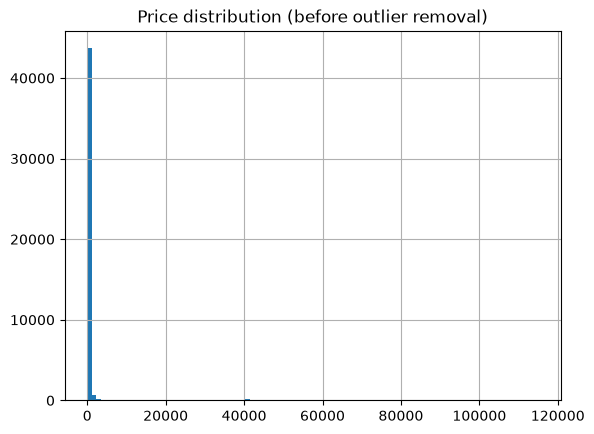

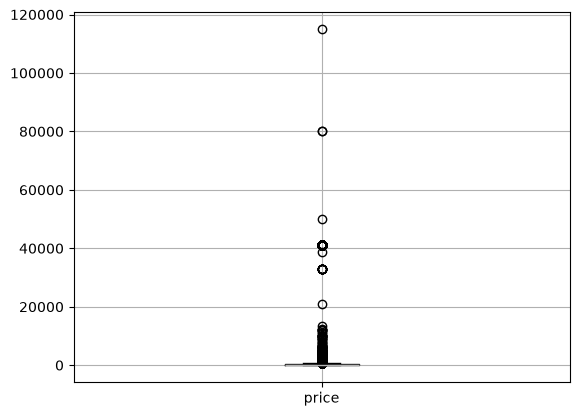

In [6]:
print(listings['price'].describe())

listings['price'].hist(bins=100)
plt.title("Price distribution (before outlier removal)")
plt.show()

listings.boxplot(column='price')
plt.show()

In [7]:
upper_cutoff = listings['price'].quantile(0.99)
print("99th percentile price:", upper_cutoff)

listings = listings[listings['price'] <= upper_cutoff]
print(listings.shape)

99th percentile price: 2178.0
(44319, 54)


count    44319.000000
mean       268.658815
std        241.611894
min         14.000000
25%        123.000000
50%        194.000000
75%        322.000000
max       2178.000000
Name: price, dtype: float64


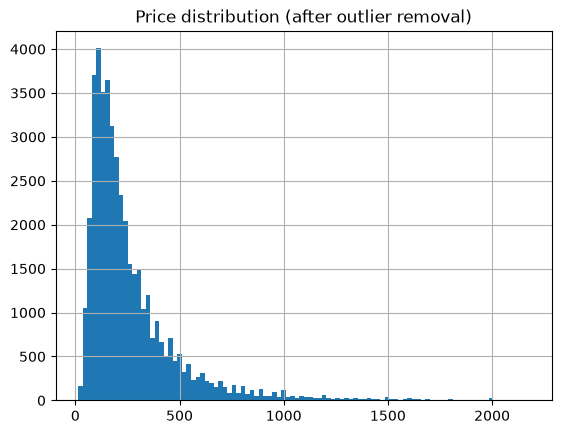

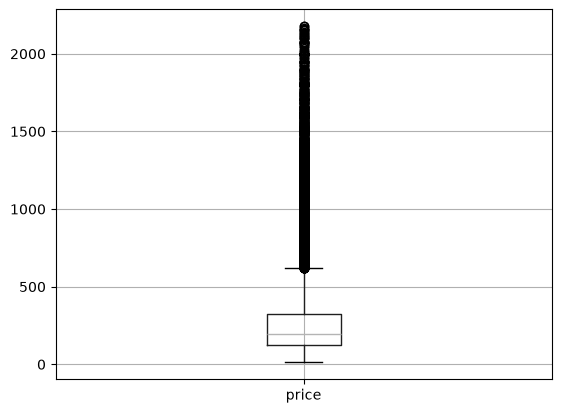

In [8]:
print(listings['price'].describe())

listings['price'].hist(bins=100)
plt.title("Price distribution (after outlier removal)")
plt.show()

listings.boxplot(column='price')
plt.show()

In [9]:
listings['bathrooms_num'] = (
    listings['bathrooms_text']
    .str.extract(r'(\d+\.?\d*)')
    .astype(float)
)

# "Half-bath" / "Shared half-bath" etc. have no digit to extract — treat as 0.5
listings.loc[
    listings['bathrooms_text'].str.contains('half', case=False, na=False) &
    listings['bathrooms_num'].isna(),
    'bathrooms_num'
] = 0.5

In [10]:
for col in ['host_response_rate', 'host_acceptance_rate']:
    listings[col] = listings[col].str.replace('%', '', regex=False).astype(float)

In [11]:
bool_cols = [
    'host_is_superhost', 'has_availability', 'instant_bookable',
    'host_identity_verified', 'host_has_profile_pic',
]
for col in bool_cols:
    listings[col] = listings[col].map({'t': 1, 'f': 0})

In [14]:
def safe_literal_eval(val):
    try:
        return ast.literal_eval(val)
    except (ValueError, TypeError):
        return []

listings['amenities_list'] = listings['amenities'].apply(safe_literal_eval)
listings['amenities_count'] = listings['amenities_list'].apply(len)

listings['host_verifications_list'] = listings['host_verifications'].apply(safe_literal_eval)
listings['host_verifications_count'] = listings['host_verifications_list'].apply(len)

In [15]:
listings = listings.drop(columns=['amenities_list', 'host_verifications_list', 'amenities', 'host_verifications'])

In [16]:
date_cols = ['host_since', 'first_review', 'last_review']
for col in date_cols:
    listings[col] = pd.to_datetime(listings[col], errors='coerce')

In [19]:
# Reviews are missing because the listing has zero reviews, not at random
# flag it, then fill with 0 rather than dropping ~11% of the data.
listings['has_reviews'] = listings['number_of_reviews'] > 0

review_score_cols = [
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value', 'reviews_per_month',
]
listings[review_score_cols] = listings[review_score_cols].fillna(0)

# bedrooms / beds / bathrooms - median within room_type (a studio's missing
# bedroom count shouldn't be filled with a whole house's median)
for col in ['bedrooms', 'beds', 'bathrooms_num']:
    listings[col] = listings.groupby('room_type')[col].transform(
        lambda s: s.fillna(s.median())
    )

# low-missing categoricals — mode imputation
for col in ['host_is_superhost', 'has_availability']:
    listings[col] = listings[col].fillna(listings[col].mode()[0])

# the ~15 rows missing nearly all host_* fields at once — negligible vs 46k, drop
listings = listings.dropna(subset=['host_since', 'host_listings_count'])

print(listings.isnull().sum().sort_values(ascending=False).head(15))

listings['has_reviews'] = listings['number_of_reviews'] > 0

review_score_cols = [
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value', 'reviews_per_month',
]
listings[review_score_cols] = listings[review_score_cols].fillna(0)

# bedrooms / beds / bathrooms — median within room_type (a studio's missing
# bedroom count shouldn't be filled with a whole house's median)
for col in ['bedrooms', 'beds', 'bathrooms_num']:
    listings[col] = listings.groupby('room_type')[col].transform(
        lambda s: s.fillna(s.median())
    )

# low-missing categoricals — mode imputation
for col in ['host_is_superhost', 'has_availability']:
    listings[col] = listings[col].fillna(listings[col].mode()[0])

# the ~15 rows missing nearly all host_* fields at once — negligible vs 46k, drop
listings = listings.dropna(subset=['host_since', 'host_listings_count'])

print(listings.isnull().sum().sort_values(ascending=False).head(15))

host_response_time           9511
host_response_rate           9511
host_location                9412
host_acceptance_rate         6174
first_review                 4766
last_review                  4766
bathrooms_text                 34
bathrooms                      25
host_listings_count             0
host_is_superhost               0
host_total_listings_count       0
host_has_profile_pic            0
longitude                       0
property_type                   0
host_identity_verified          0
dtype: int64
host_response_time           9511
host_response_rate           9511
host_location                9412
host_acceptance_rate         6174
first_review                 4766
last_review                  4766
bathrooms_text                 34
bathrooms                      25
host_listings_count             0
host_is_superhost               0
host_total_listings_count       0
host_has_profile_pic            0
longitude                       0
property_type                   0
h

In [20]:
print("Duplicate rows:", listings.duplicated().sum())
listings = listings.drop_duplicates()

Duplicate rows: 0


In [21]:
os.makedirs('data/processed', exist_ok=True)
listings.to_csv('data/processed/listings_clean.csv', index=False)

print("Final shape:", listings.shape)

Final shape: (44304, 56)
